# Trend Scout — мультиагентний research-дайджест на LangGraph

**Фінальний проєкт** · курс Generative AI Developer (robot_dreams) · Роман Мицько · липень 2026

Репозиторій: https://github.com/RomanMytsko/trend-scout

**Ідея.** Щотижневий моніторинг agentic-новин — рутина з чіткою декомпозицією: знайти → відібрати → написати → перевірити. Trend Scout автоматизує її мультиагентною системою за патерном **orchestrator–workers**:

```
planner ──> researcher ──> curator ──> writer ──> judge ──> archive ──> END
   ^            │                        ^          │
   └── replan ──┘ (мало матеріалу)       └─ revise ─┘ (оцінка < 4.0)
```

| Вузол | Тип | Відповідальність |
|---|---|---|
| planner | LLM-агент | декомпозиція тем у пошукові запити (structured output) |
| researcher | tool-воркер | RSS + DDG news; дедуплікація за URL і семантична (embeddings), фільтр памʼяті |
| curator | LLM-агент | ранжування/фільтрація під аудиторію, відсів маркетингу |
| writer | LLM-агент | дайджест у строгому форматі; враховує фідбек judge |
| judge | guardrail + LLM-as-a-judge | URL-allowlist перевірка + рубрика 1–5 за 3 критеріями |
| archive | памʼять | зберігає доставлені сюжети в Chroma, щоб прогони не повторювались |

Дві петлі зворотного звʼязку (replan і revise) обмежені лічильниками — гарантія завершення.

In [1]:
%pip install -q git+https://github.com/RomanMytsko/trend-scout.git

Note: you may need to restart the kernel to use updated packages.


## API-ключ

Потрібен лише `OPENAI_API_KEY` (пошук і RSS — безключові). У Colab додай ключ у **Secrets** (іконка 🔑 зліва) або введи нижче.

In [2]:
import os

if not os.environ.get("OPENAI_API_KEY"):
    try:
        from google.colab import userdata
        os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
    except Exception:
        import getpass
        os.environ["OPENAI_API_KEY"] = getpass.getpass("OPENAI_API_KEY: ")

# Мова дайджесту і аудиторія конфігуруються через env (див. .env.example)
os.environ.setdefault("DIGEST_LANGUAGE", "Ukrainian")
os.environ.setdefault("AUDIENCE", "backend Python engineer")
print("OK")

OK


## Візуалізація графа

LangGraph компілює `StateGraph` з умовними переходами — подивимось на нього.

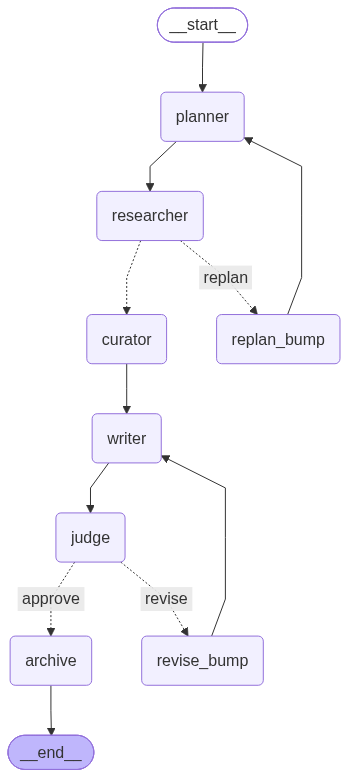

In [3]:
from trend_scout import graph

app = graph.build_graph()

try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print(app.get_graph().draw_mermaid())  # fallback: mermaid-текст

## Запуск пайплайну

Теми можна міняти на свої. Виконання ~1–3 хв: RSS-фіди, кілька пошукових запитів і 4–6 LLM-викликів.

In [4]:
TOPICS = [
    "multi-agent orchestration",
    "MCP and A2A protocols",
    "LangGraph and agent frameworks",
    "context engineering",
]

state = graph.run_digest(TOPICS)

print("--- pipeline events ---")
for event in state["events"]:
    print(" ", event)

Web search failed for query 'multi-agent orchestration latest developments 2024'
Traceback (most recent call last):
  File "/Users/roman/Desktop/rm_repos/robodreams/trend-scout/.venv/lib/python3.14/site-packages/trend_scout/tools.py", line 67, in web_search
    results = list(ddgs.news(query, max_results=max_results, timelimit="w"))
                   ~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/roman/Desktop/rm_repos/robodreams/trend-scout/.venv/lib/python3.14/site-packages/ddgs/ddgs.py", line 466, in news
    return self._search_sync("news", query, **kwargs)
           ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/roman/Desktop/rm_repos/robodreams/trend-scout/.venv/lib/python3.14/site-packages/ddgs/ddgs.py", line 454, in _search_sync
    raise DDGSException(err or "No results found.")
ddgs.exceptions.DDGSException: No results found.


Web search failed for query 'MCP protocol implementation in Python 2024'
Traceback (most recent call last):
  File "/Users/roman/Desktop/rm_repos/robodreams/trend-scout/.venv/lib/python3.14/site-packages/trend_scout/tools.py", line 67, in web_search
    results = list(ddgs.news(query, max_results=max_results, timelimit="w"))
                   ~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/roman/Desktop/rm_repos/robodreams/trend-scout/.venv/lib/python3.14/site-packages/ddgs/ddgs.py", line 466, in news
    return self._search_sync("news", query, **kwargs)
           ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/roman/Desktop/rm_repos/robodreams/trend-scout/.venv/lib/python3.14/site-packages/ddgs/ddgs.py", line 454, in _search_sync
    raise DDGSException(err or "No results found.")
ddgs.exceptions.DDGSException: No results found.


Web search failed for query 'LangGraph framework updates April 2024'
Traceback (most recent call last):
  File "/Users/roman/Desktop/rm_repos/robodreams/trend-scout/.venv/lib/python3.14/site-packages/trend_scout/tools.py", line 67, in web_search
    results = list(ddgs.news(query, max_results=max_results, timelimit="w"))
                   ~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/roman/Desktop/rm_repos/robodreams/trend-scout/.venv/lib/python3.14/site-packages/ddgs/ddgs.py", line 466, in news
    return self._search_sync("news", query, **kwargs)
           ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/roman/Desktop/rm_repos/robodreams/trend-scout/.venv/lib/python3.14/site-packages/ddgs/ddgs.py", line 454, in _search_sync
    raise DDGSException(err or "No results found.")
ddgs.exceptions.DDGSException: No results found.


Web search failed for query 'context engineering techniques backend systems 2024 April updates'
Traceback (most recent call last):
  File "/Users/roman/Desktop/rm_repos/robodreams/trend-scout/.venv/lib/python3.14/site-packages/trend_scout/tools.py", line 67, in web_search
    results = list(ddgs.news(query, max_results=max_results, timelimit="w"))
                   ~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/roman/Desktop/rm_repos/robodreams/trend-scout/.venv/lib/python3.14/site-packages/ddgs/ddgs.py", line 466, in news
    return self._search_sync("news", query, **kwargs)
           ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/roman/Desktop/rm_repos/robodreams/trend-scout/.venv/lib/python3.14/site-packages/ddgs/ddgs.py", line 454, in _search_sync
    raise DDGSException(err or "No results found.")
ddgs.exceptions.DDGSException: No results found.


--- pipeline events ---
  planner: 6 queries
  researcher: 46 rss + search -> 48 unique items
  researcher: semantic dedupe 48 -> 47 stories
  curator: picked 5 items
  writer: draft #0 ready
  judge: relevance=5 grounding=5 format=4 avg=4.67
  archive: remembered 5 delivered stories


## Оцінка якості (LLM-as-a-judge)

Перед рубрикою LLM-судді спрацьовує **детермінований guardrail**: усі лінки в дайджесті мають входити до allowlist зібраних URL (захист від галюцинованих джерел і prompt injection у сніпетах).

In [5]:
verdict = state["verdict"]
print(f"relevance    : {verdict.relevance}/5")
print(f"grounding    : {verdict.grounding}/5")
print(f"format       : {verdict.format_score}/5")
print(f"average      : {verdict.average:.2f} (поріг 4.0)")
print(f"ревізій      : {state.get('revisions', 0)}")
print(f"replan-ів    : {state.get('replans', 0)}")
print(f"\nфідбек судді: {verdict.feedback}")

relevance    : 5/5
grounding    : 5/5
format       : 4/5
average      : 4.67 (поріг 4.0)
ревізій      : 0
replan-ів    : 0

фідбек судді: The digest is highly relevant to the topics of multi-agent orchestration and agent frameworks, and it is well-targeted at backend Python engineers. All claims are well grounded in the source items with accurate titles, summaries, and correct URLs. The format mostly follows the required Ukrainian structure with a title, intro, and per-item sections labeled 'Суть', 'Чому важливо', and 'Лінк'. However, the digest uses numbered sections (e.g., '## 1.') which is not explicitly required and might be simplified to just bullet points or headings without numbering. Also, the intro could be slightly expanded to better set the context for the audience. Otherwise, the structure and language are appropriate and clear.


## Результат — дайджест

In [6]:
from IPython.display import Markdown, display

display(Markdown(state["digest"]))

# Останні дослідження в мультиагентних системах для бекенд Python-інженерів

Цей дайджест охоплює нові наукові роботи про мультиагентні системи, які мають значення для розробників бекенд-сервісів на Python, що працюють з агентами та їх оркестрацією.

## 1. Bad Memory: Evaluating Prompt Injection Risks from Memory in Agentic Systems  
- Суть: Агентські системи зберігають стан у пам’яті між сесіями, що підвищує їх корисність, але створює ризики ін’єкції шкідливих інструкцій у пам’яті. У роботі досліджують ці атаки на прикладі двох систем Anthropic Claude Code та OpenAI Codex.  
- Чому важливо: Розуміння вразливостей пам’яті допоможе створювати безпечніші бекенд-системи з агентами, що зберігають стан.  
- Лінк: [arXiv:2607.14611v1](https://arxiv.org/abs/2607.14611v1)  

## 2. Towards an Intention Abstraction Layer for Autonomous Industrial Systems  
- Суть: Запропоновано проміжний шар Intention Abstraction Layer (IAL), який зберігає високорівневі наміри у промислових автономних підсистемах, щоб уникнути конфліктів цілей і покращити координацію.  
- Чому важливо: IAL допоможе краще управляти складними мультиагентними системами в промислових бекенд-середовищах.  
- Лінк: [arXiv:2607.14553v1](https://arxiv.org/abs/2607.14553v1)  

## 3. World-Model-Aware Responsibility Allocation in Heterogeneous Logistics Systems  
- Суть: Представлено фреймворк WMARF для динамічного розподілу відповідальності між автономним обладнанням і центральною системою на основі якості моделей світу.  
- Чому важливо: Це дозволяє уникати конфліктів і блокувань у мультиагентних логістичних системах, що актуально для бекенд-інженерів, які розробляють складні системи управління.  
- Лінк: [arXiv:2607.14550v1](https://arxiv.org/abs/2607.14550v1)  

## 4. Digital Pantheon: Simulating and Auditing Coalition Formation with LLM Agents  
- Суть: Розроблено мультиагентний фреймворк для моделювання формування політичних коаліцій із LLM-агентів, що поєднує навчання з підкріпленням і генерацію з пошуком.  
- Чому важливо: Цей підхід демонструє, як можна керувати поведінкою агентів з урахуванням ідеологічних уподобань, що корисно для складних систем оркестрації агентів.  
- Лінк: [arXiv:2607.15095v1](https://arxiv.org/abs/2607.15095v1)  

## 5. Stigmergic Graph Memory: An Environment-Aware Approach for Many-to-Many Multi-Agent Pickup and Delivery  
- Суть: Запропоновано метод Stigmergic Graph Memory, який використовує пам’ять про останні дії агентів для покращення маршрутизації у багатозадачних системах доставки.  
- Чому важливо: Цей підхід допоможе ефективніше координувати багатоагентні системи доставки, що важливо для бекенд-інженерів, які працюють з оркестрацією агентів.  
- Лінк: [arXiv:2607.15182v1](https://arxiv.org/abs/2607.15182v1)

## Зазирнемо всередину: проміжні стани агентів

In [7]:
print("PLAN (planner, structured output):")
print("  reasoning:", state["plan"].reasoning)
for q in state["plan"].queries:
    print("  query:", q)

print(f"\nITEMS (researcher): {len(state['items'])} зібрано, приклади:")
for item in state["items"][:5]:
    print(f"  [{item.source}] {item.title[:80]}")

print("\nCURATION (curator):")
for pick in state["curation"].picks:
    print(f"  #{pick.index} relevance={pick.relevance}: {pick.why_it_matters[:100]}")

PLAN (planner, structured output):
  reasoning: To cover the topics comprehensively for a backend Python engineer, the queries focus on recent developments and practical implementations in multi-agent orchestration, MCP and A2A protocols, LangGraph and agent frameworks, and context engineering. The queries are designed to find technical articles, tutorials, and research updates from the last week without broadening beyond the specified topics, ensuring relevance and depth.
  query: multi-agent orchestration latest developments 2024
  query: MCP protocol implementation in Python 2024
  query: A2A communication protocols for agents 2024
  query: LangGraph framework updates April 2024
  query: agent frameworks comparison Python 2024
  query: context engineering techniques backend systems 2024 April updates

ITEMS (researcher): 47 зібрано, приклади:
  [Hacker News (front page)] Clever hacker fits 537,000 domains in a $5 ESP32 ad-blocking dongle
  [Hacker News (front page)] DRIVE – Operatio

## Семантична дедуплікація і памʼять між прогонами

Два застосування embeddings (`text-embedding-3-small`):

- **Semantic dedupe** — той самий сюжет, передрукований різними виданнями, схлопується до одного айтема (greedy cosine clustering, поріг 0.86). URL-дедуплікація такого не ловить.
- **Cross-run memory** — після апруву судді вузол `archive` зберігає доставлені сюжети в ChromaDB; наступний прогін відкидає семантично близькі кандидати (поріг 0.88), тож тижневі дайджести не повторюються.

У подіях вище це видно як `semantic: dedupe N -> M` і `memory: dropped K already-covered`. Запусти пайплайн двічі — другий прогін відфільтрує вже доставлені сюжети (памʼять у Colab живе в межах сесії, локально — у `.trend_scout_memory/`).

## Висновки

- **Патерн orchestrator–workers** реалізований на LangGraph: LLM-агенти планують/курують/пишуть, детермінований воркер виконує інструменти.
- **Structured outputs (Pydantic)** у кожного агента — жодного парсингу вільного тексту.
- **LLM-as-a-judge** як quality gate з петлею ревізій і порогом 4.0.
- **Embeddings у двох ролях**: семантична дедуплікація сюжетів і Chroma-памʼять доставленого між прогонами.
- **Guardrails проти prompt injection**: санітизація контенту, явне маркування untrusted-даних у промптах, детермінований URL-allowlist.
- **Надійність** як у бекенд-системах: graceful degradation інструментів, capped retries, event log.

Можливий розвиток: доставка в Telegram, розклад на Celery beat / cron, A2A-інтерфейс для інших агентів.